# Web Performance Analysis: Loading Time Deep Dive (Google.com)

**Analysis Period:** Dynamically updated from first to latest data point  
**Dataset:** Playwright-based webpage loading measurements (updated hourly)  
**Objective:** Comprehensive performance analysis across concurrency levels and time

---

## Table of Contents

1. [Setup & Imports](#1.-Setup-&-Imports)
2. [Data Loading](#2.-Data-Loading)
3. [Data Cleaning & Validation](#3.-Data-Cleaning-&-Validation)
4. [Feature Engineering](#4.-Feature-Engineering)
5. [Exploratory Data Analysis](#5.-Exploratory-Data-Analysis)
6. [Time Series Analysis](#6.-Time-Series-Analysis)
7. [Statistical Analysis](#7.-Statistical-Analysis)
8. [Anomaly Detection](#8.-Anomaly-Detection)
9. [Performance Insights & Conclusions](#9.-Performance-Insights-&-Conclusions)

---

## 1. Setup & Imports

Loading all required libraries and configuring visualization settings.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("✓ Core libraries loaded")

✓ Core libraries loaded


In [2]:
# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

print("✓ Visualization libraries loaded")

✓ Visualization libraries loaded


In [3]:
!pip install statsmodels --quiet

from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, iqr
from statsmodels.tsa.seasonal import seasonal_decompose
from itertools import combinations

print("✓ Statistical libraries loaded")

✓ Statistical libraries loaded


In [4]:
# Visualization configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print("✓ Configuration complete")

✓ Configuration complete


## 2. Data Loading

Loading the CSV dataset containing webpage loading time measurements.

In [5]:
# Load dataset
df = pd.read_csv('loading_times.csv', 
                 names=['timestamp', 'concurrency_level', 'load_time_ms'],
                 parse_dates=['timestamp'])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Duration: {(df['timestamp'].max() - df['timestamp'].min()).days} days")
print(f"\nConcurrency Levels: {sorted(df['concurrency_level'].unique())}")

Dataset Shape: (42085, 3)
Date Range: 2025-03-16 17:18:42.752000+00:00 to 2026-03-26 21:21:02.221000+00:00
Duration: 375 days

Concurrency Levels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [6]:
# Display first few rows
df.head()

,timestamp,concurrency_level,load_time_ms
0,2025-03-16 17:18:42.752000+00:00,1,1333.20
1,2025-03-16 17:18:50.583000+00:00,2,1349.20
2,2025-03-16 17:18:58.508000+00:00,3,1302.20
3,2025-03-16 17:19:06.576000+00:00,4,1289.80
4,2025-03-16 17:19:15.437000+00:00,5,1396.36


## 3. Data Cleaning & Validation

### 3.1 Missing Data Assessment

In [7]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
timestamp            0
concurrency_level    0
load_time_ms         0
dtype: int64

Total missing: 0


In [8]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Display data types
print(f"\nData Types:")
print(df.dtypes)

Duplicate rows: 0

Data Types:
timestamp            datetime64[us, UTC]
concurrency_level                  int64
load_time_ms                     float64
dtype: object


### 3.2 Outlier Detection & Analysis

In [9]:
# Statistical summary of load times
print("Load Time Statistics (ms):")
df['load_time_ms'].describe()

Load Time Statistics (ms):


count    42085.00
mean       756.12
std        373.36
min        315.80
25%        544.00
50%        692.73
75%        868.75
max      16870.00
Name: load_time_ms, dtype: float64

In [10]:
# IQR method for outlier detection
Q1 = df['load_time_ms'].quantile(0.25)
Q3 = df['load_time_ms'].quantile(0.75)
IQR_value = Q3 - Q1
lower_bound = Q1 - 3 * IQR_value
upper_bound = Q3 + 3 * IQR_value

outliers = df[(df['load_time_ms'] < lower_bound) | (df['load_time_ms'] > upper_bound)]

print(f"Outliers detected (3×IQR method): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Lower bound: {lower_bound:.2f} ms")
print(f"Upper bound: {upper_bound:.2f} ms")

Outliers detected (3×IQR method): 641 (1.52%)
Lower bound: -430.25 ms
Upper bound: 1843.00 ms


In [11]:
# Create clean dataset
df_clean = df[(df['load_time_ms'] >= lower_bound) & (df['load_time_ms'] <= upper_bound)].copy()
print(f"Clean dataset size: {len(df_clean)} ({len(df_clean)/len(df)*100:.2f}% retained)")

Clean dataset size: 41444 (98.48% retained)


### 3.3 Distribution Validation

In [12]:
# Test for normality (Shapiro-Wilk test on sample)
sample_size = min(5000, len(df_clean))
sample_data = df_clean['load_time_ms'].sample(sample_size, random_state=42)
statistic, p_value = stats.shapiro(sample_data)

print(f"Shapiro-Wilk Test for Normality:")
print(f"Statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Distribution is {'NOT normal' if p_value < 0.05 else 'approximately normal'} (α=0.05)")

Shapiro-Wilk Test for Normality:
Statistic: 0.9287
P-value: 1.1016e-43
Distribution is NOT normal (α=0.05)


In [13]:
# Skewness and kurtosis
skewness = stats.skew(df_clean['load_time_ms'])
kurt = stats.kurtosis(df_clean['load_time_ms'])

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")
print(f"\nInterpretation:")
print(f"  - Skewness: {'Right-skewed' if skewness > 0 else 'Left-skewed'} distribution")
print(f"  - Kurtosis: {'Heavy-tailed' if kurt > 0 else 'Light-tailed'} distribution")

Skewness: 1.1107
Kurtosis: 1.7010

Interpretation:
  - Skewness: Right-skewed distribution
  - Kurtosis: Heavy-tailed distribution


## 4. Feature Engineering

### 4.1 Temporal Features

Extracting time-based features from timestamps.

In [14]:
# Extract temporal features
df_clean['date'] = df_clean['timestamp'].dt.date
df_clean['hour'] = df_clean['timestamp'].dt.hour
df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
df_clean['day_name'] = df_clean['timestamp'].dt.day_name()
df_clean['month'] = df_clean['timestamp'].dt.month
df_clean['week'] = df_clean['timestamp'].dt.isocalendar().week

print("Temporal features extracted:")
print("  - date, hour, day_of_week, day_name, month, week")

Temporal features extracted:
  - date, hour, day_of_week, day_name, month, week


In [15]:
# Display sample with new features
df_clean[['timestamp', 'hour', 'day_name', 'month', 'load_time_ms']].head()

,timestamp,hour,day_name,month,load_time_ms
0,2025-03-16 17:18:42.752000+00:00,17,Sunday,3,1333.20
1,2025-03-16 17:18:50.583000+00:00,17,Sunday,3,1349.20
2,2025-03-16 17:18:58.508000+00:00,17,Sunday,3,1302.20
3,2025-03-16 17:19:06.576000+00:00,17,Sunday,3,1289.80
4,2025-03-16 17:19:15.437000+00:00,17,Sunday,3,1396.36


### 4.2 Rolling Statistics

Calculating rolling averages for trend analysis.

In [16]:
# Sort by timestamp for rolling calculations
df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)
print(f"Data sorted by timestamp: {len(df_clean)} records")

Data sorted by timestamp: 41444 records


In [17]:
# Calculate 7-day rolling average by concurrency level
df_clean['rolling_7d_mean'] = df_clean.groupby('concurrency_level')['load_time_ms'].transform(
    lambda x: x.rolling(window=168, min_periods=1, center=False).mean()
)
print("✓ 7-day rolling average calculated")

✓ 7-day rolling average calculated


In [18]:
# Calculate 30-day rolling average by concurrency level
df_clean['rolling_30d_mean'] = df_clean.groupby('concurrency_level')['load_time_ms'].transform(
    lambda x: x.rolling(window=720, min_periods=1, center=False).mean()
)
print("✓ 30-day rolling average calculated")

✓ 30-day rolling average calculated


### 4.3 Percentile Calculations

In [19]:
# Calculate percentiles by concurrency level
percentiles = df_clean.groupby('concurrency_level')['load_time_ms'].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
)[['50%', '90%', '95%', '99%']]
percentiles.columns = ['p50', 'p90', 'p95', 'p99']

print("Percentiles by Concurrency Level:")
percentiles

Percentiles by Concurrency Level:


,p50,p90,p95,p99
concurrency_level,,,,
1,481.00,736.84,834.66,1213.04
2,543.80,769.53,844.85,1242.45
3,644.97,902.77,982.84,1349.31
4,770.65,1096.45,1197.42,1522.38
5,926.36,1300.67,1406.57,1674.12


## 5. Exploratory Data Analysis

### 5.1 Load Time Over Time

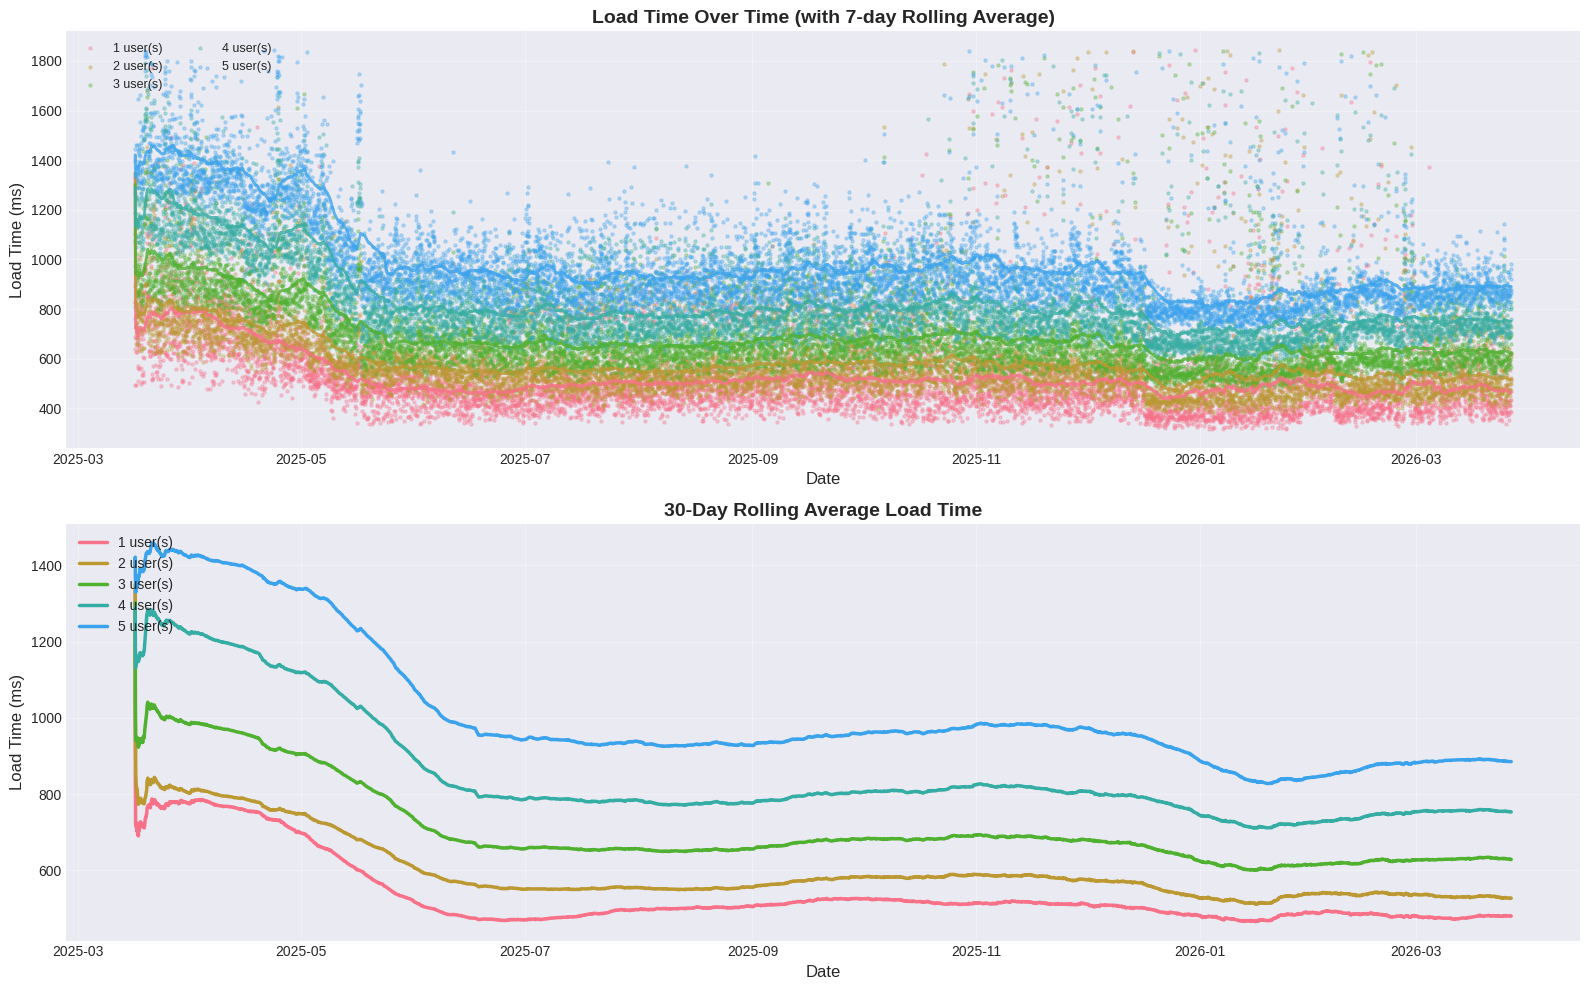

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Raw data with 7-day rolling average
for level in sorted(df_clean['concurrency_level'].unique()):
    data = df_clean[df_clean['concurrency_level'] == level]
    axes[0].scatter(data['timestamp'], data['load_time_ms'],
                   alpha=0.3, s=5, label=f'{level} user(s)')
    axes[0].plot(data['timestamp'], data['rolling_7d_mean'],
                linewidth=2, alpha=0.8)

axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Load Time (ms)', fontsize=12)
axes[0].set_title('Load Time Over Time (with 7-day Rolling Average)', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9, ncol=2)
axes[0].grid(True, alpha=0.3)

# Plot 2: 30-day rolling average
for level in sorted(df_clean['concurrency_level'].unique()):
    data = df_clean[df_clean['concurrency_level'] == level]
    axes[1].plot(data['timestamp'], data['rolling_30d_mean'],
                linewidth=2.5, label=f'{level} user(s)')

axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Load Time (ms)', fontsize=12)
axes[1].set_title('30-Day Rolling Average Load Time', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Distribution Analysis

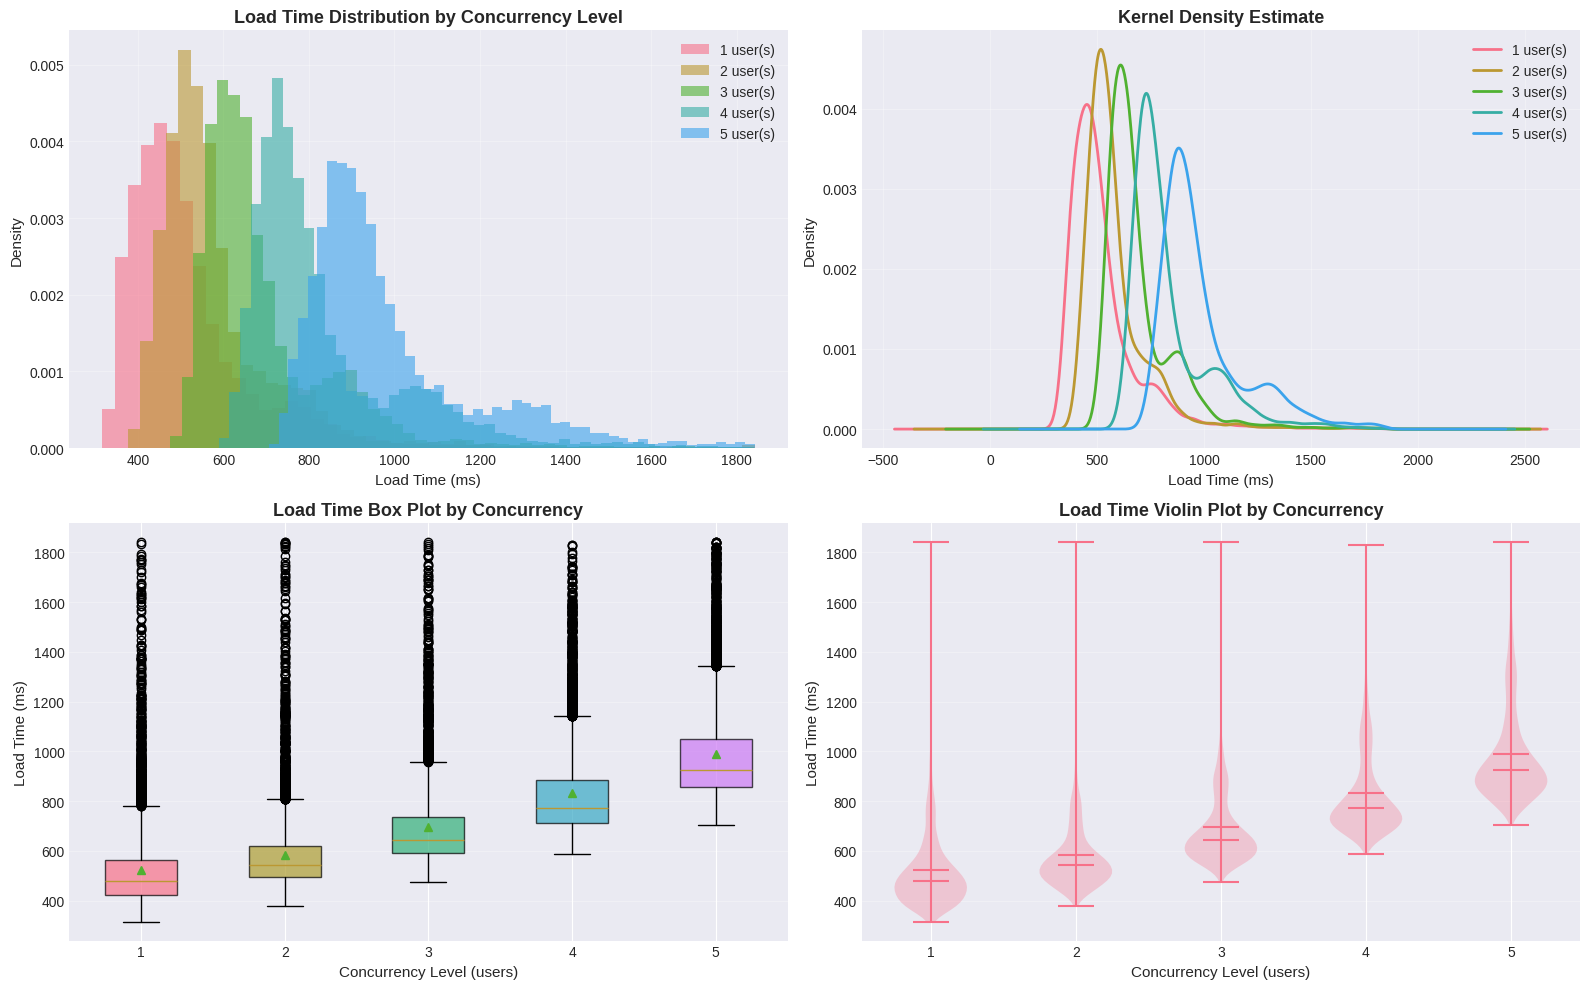

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Histogram
for level in sorted(df_clean['concurrency_level'].unique()):
    data = df_clean[df_clean['concurrency_level'] == level]['load_time_ms']
    axes[0, 0].hist(data, bins=50, alpha=0.6, label=f'{level} user(s)', density=True)

axes[0, 0].set_xlabel('Load Time (ms)', fontsize=11)
axes[0, 0].set_ylabel('Density', fontsize=11)
axes[0, 0].set_title('Load Time Distribution by Concurrency Level', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: KDE plot
for level in sorted(df_clean['concurrency_level'].unique()):
    data = df_clean[df_clean['concurrency_level'] == level]['load_time_ms']
    data.plot(kind='kde', ax=axes[0, 1], label=f'{level} user(s)', linewidth=2)

axes[0, 1].set_xlabel('Load Time (ms)', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].set_title('Kernel Density Estimate', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Box plot
boxplot_data = [df_clean[df_clean['concurrency_level'] == level]['load_time_ms'].values
                for level in sorted(df_clean['concurrency_level'].unique())]
box = axes[1, 0].boxplot(boxplot_data, labels=sorted(df_clean['concurrency_level'].unique()),
                         patch_artist=True, showmeans=True)

colors = sns.color_palette('husl', len(boxplot_data))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 0].set_xlabel('Concurrency Level (users)', fontsize=11)
axes[1, 0].set_ylabel('Load Time (ms)', fontsize=11)
axes[1, 0].set_title('Load Time Box Plot by Concurrency', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Violin plot
concurrency_order = sorted(df_clean['concurrency_level'].unique())
axes[1, 1].violinplot([df_clean[df_clean['concurrency_level'] == level]['load_time_ms'].values
                        for level in concurrency_order],
                       positions=concurrency_order,
                       showmeans=True, showmedians=True)

axes[1, 1].set_xlabel('Concurrency Level (users)', fontsize=11)
axes[1, 1].set_ylabel('Load Time (ms)', fontsize=11)
axes[1, 1].set_title('Load Time Violin Plot by Concurrency', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_xticks(concurrency_order)

plt.tight_layout()
plt.show()

In [22]:
# Summary statistics by concurrency level
print("Summary Statistics by Concurrency Level:")
df_clean.groupby('concurrency_level')['load_time_ms'].describe()

Summary Statistics by Concurrency Level:


,count,mean,std,min,25%,50%,75%,max
concurrency_level,,,,,,,,
1,8299.0,525.25,170.30,315.80,421.2,481.00,565.20,1842.20
2,8290.0,585.02,158.90,376.60,493.3,543.80,619.38,1842.00
3,8288.0,694.37,163.73,474.67,591.0,644.97,738.25,1840.27
4,8297.0,833.33,183.79,589.00,714.0,770.65,885.10,1831.95
5,8270.0,990.19,199.51,706.00,858.0,926.36,1051.95,1842.76


### 5.3 Temporal Patterns (Heatmaps)

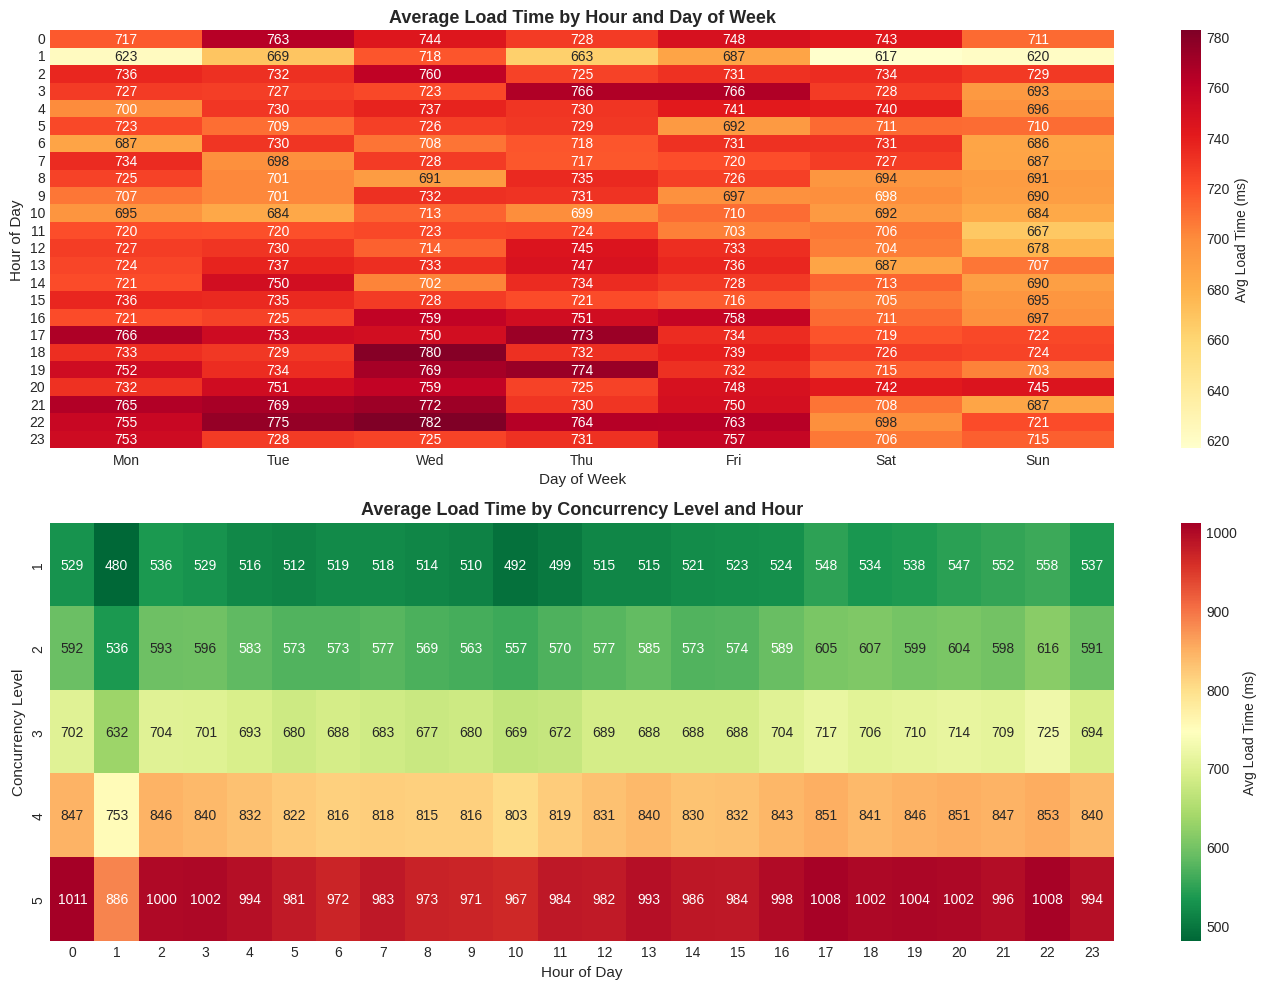

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Heatmap 1: Hour vs Day of week
pivot_all = df_clean.pivot_table(
    values='load_time_ms',
    index='hour',
    columns='day_of_week',
    aggfunc='mean'
)

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.heatmap(pivot_all, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': 'Avg Load Time (ms)'},
            xticklabels=day_labels, ax=axes[0])
axes[0].set_title('Average Load Time by Hour and Day of Week', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day of Week', fontsize=11)
axes[0].set_ylabel('Hour of Day', fontsize=11)

# Heatmap 2: Concurrency vs Hour
pivot_conc = df_clean.pivot_table(
    values='load_time_ms',
    index='concurrency_level',
    columns='hour',
    aggfunc='mean'
)

sns.heatmap(pivot_conc, annot=True, fmt='.0f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Avg Load Time (ms)'}, ax=axes[1])
axes[1].set_title('Average Load Time by Concurrency Level and Hour', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=11)
axes[1].set_ylabel('Concurrency Level', fontsize=11)

plt.tight_layout()
plt.show()

## 6. Time Series Analysis

### 6.1 Time Series Decomposition

In [24]:
daily_agg = df_clean.groupby(['date', 'concurrency_level'])['load_time_ms'].mean().reset_index()
ts_data = daily_agg[daily_agg['concurrency_level'] == 3].set_index('date')['load_time_ms']
ts_data.index = pd.to_datetime(ts_data.index)
ts_data = ts_data.sort_index()
decomposition = seasonal_decompose(ts_data, model='additive', period=7, extrapolate_trend='freq')
print(f"✓ Decomposition complete: {len(ts_data)} days")

✓ Decomposition complete: 376 days


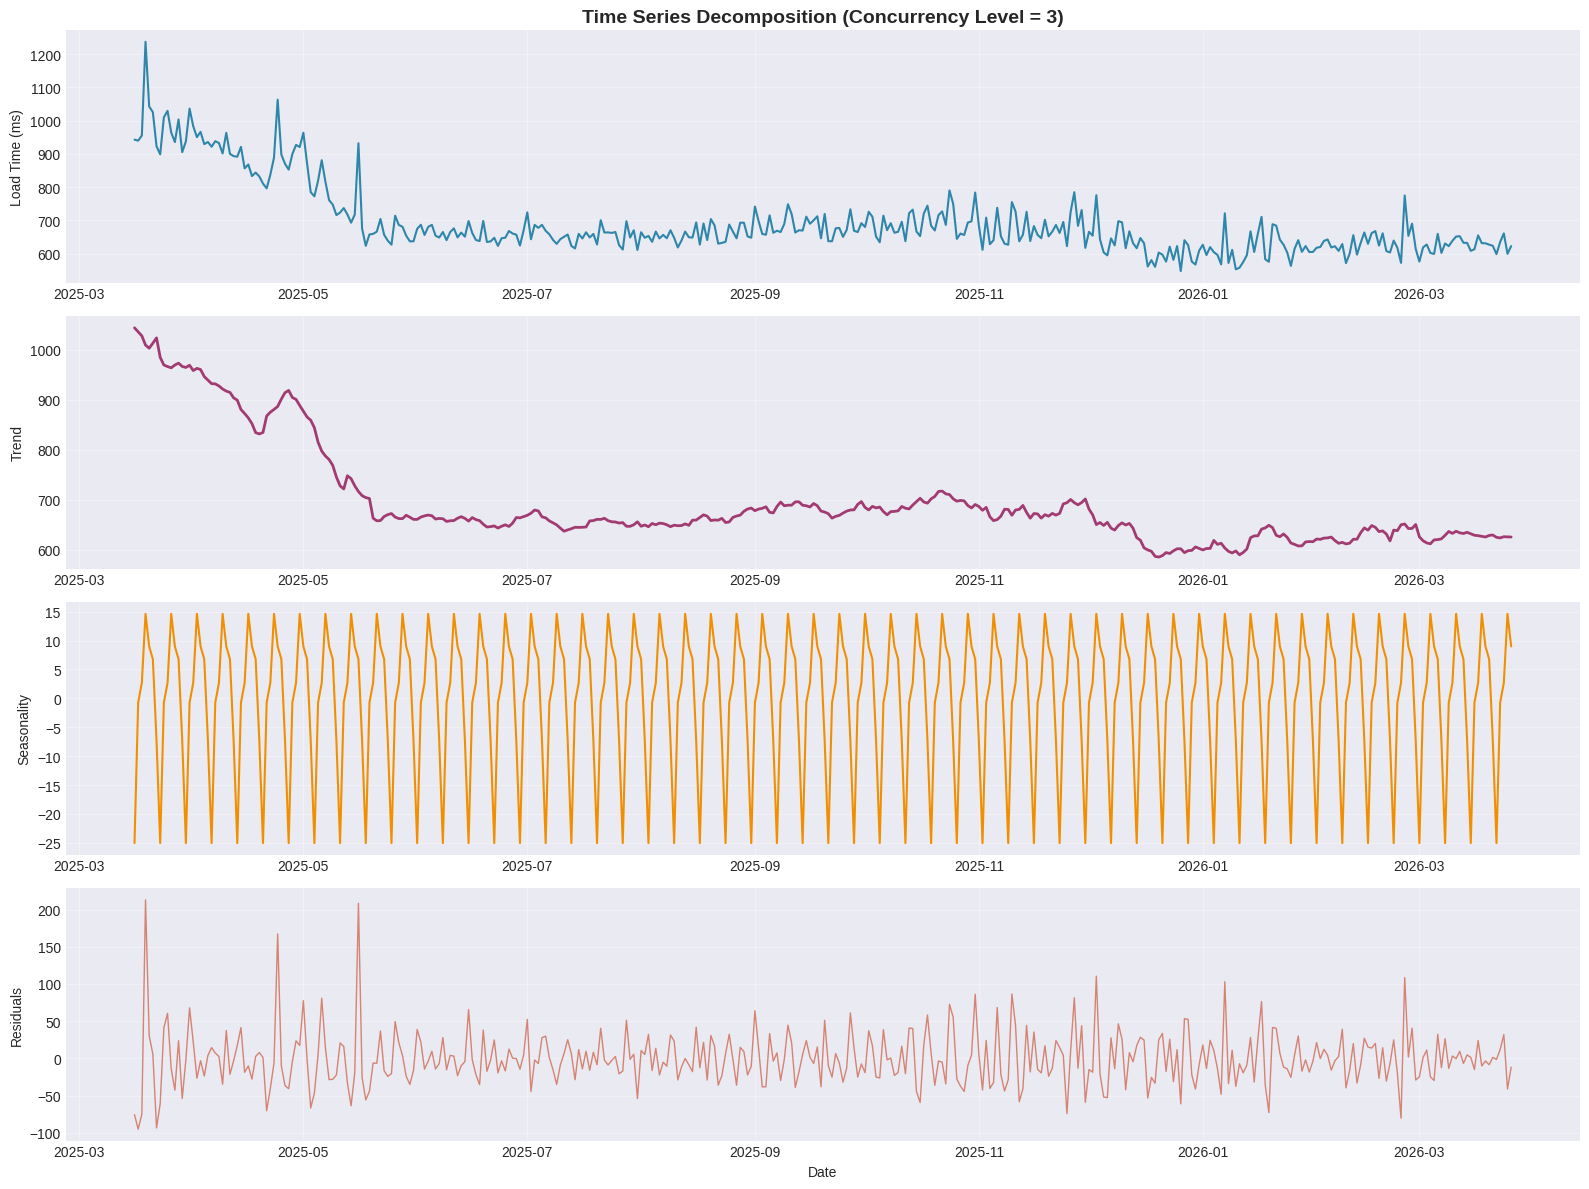

In [25]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
axes[0].plot(ts_data.index, ts_data.values, linewidth=1.5, color='#2E86AB')
axes[0].set_ylabel('Load Time (ms)')
axes[0].set_title('Time Series Decomposition (Concurrency Level = 3)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition.trend.index, decomposition.trend.values, linewidth=2, color='#A23B72')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, linewidth=1.5, color='#F18F01')
axes[2].set_ylabel('Seasonality')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomposition.resid.index, decomposition.resid.values, linewidth=1, color='#C73E1D', alpha=0.6)
axes[3].set_ylabel('Residuals')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Early vs Late Period Comparison

In [26]:
min_date = df_clean['timestamp'].min()
max_date = df_clean['timestamp'].max()
split = (max_date - min_date) / 2
df_early = df_clean[df_clean['timestamp'] <= min_date + split/2]
df_late = df_clean[df_clean['timestamp'] >= max_date - split/2]
print(f"Early: {len(df_early)} records, Late: {len(df_late)} records")

Early: 10652 records, Late: 9755 records


In [27]:
comparison = pd.DataFrame({
    'Early_Mean': df_early.groupby('concurrency_level')['load_time_ms'].mean(),
    'Late_Mean': df_late.groupby('concurrency_level')['load_time_ms'].mean()
})
comparison['Change_%'] = ((comparison['Late_Mean'] - comparison['Early_Mean']) / comparison['Early_Mean'] * 100)
print("Performance Change:")
comparison.round(2)

Performance Change:


,Early_Mean,Late_Mean,Change_%
concurrency_level,,,
1,607.11,479.89,-20.96
2,673.57,531.22,-21.13
3,815.02,622.09,-23.67
4,999.26,741.34,-25.81
5,1189.79,868.41,-27.01


## 7. Statistical Analysis

### 7.1 Kruskal-Wallis Test

In [28]:
groups = [df_clean[df_clean['concurrency_level'] == l]['load_time_ms'].values for l in sorted(df_clean['concurrency_level'].unique())]
h_stat, p_val = kruskal(*groups)
print(f"H-statistic: {h_stat:.4f}, P-value: {p_val:.10f}")
print(f"Result: {'Significant' if p_val < 0.05 else 'Not significant'} (α=0.05)")

H-statistic: 24811.6318, P-value: 0.0000000000
Result: Significant (α=0.05)


### 7.2 Confidence Intervals

In [29]:
ci_data = []
for level in sorted(df_clean['concurrency_level'].unique()):
    data = df_clean[df_clean['concurrency_level'] == level]['load_time_ms']
    mean = data.mean()
    ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=stats.sem(data))
    ci_data.append({'Level': level, 'Mean': mean, 'CI_Lower': ci[0], 'CI_Upper': ci[1]})
    print(f"Level {level}: {mean:.2f} ms, 95% CI: [{ci[0]:.2f}, {ci[1]:.2f}]")
ci_df = pd.DataFrame(ci_data)

Level 1: 525.25 ms, 95% CI: [521.58, 528.91]
Level 2: 585.02 ms, 95% CI: [581.60, 588.44]
Level 3: 694.37 ms, 95% CI: [690.85, 697.90]
Level 4: 833.33 ms, 95% CI: [829.38, 837.29]
Level 5: 990.19 ms, 95% CI: [985.89, 994.49]


## 8. Anomaly Detection

### 8.1 Z-Score Method

In [30]:
df_clean['z_score'] = df_clean.groupby('concurrency_level')['load_time_ms'].transform(lambda x: np.abs(stats.zscore(x)))
df_clean['is_anomaly_z'] = df_clean['z_score'] > 3
print(f"Z-score anomalies: {df_clean['is_anomaly_z'].sum()} ({df_clean['is_anomaly_z'].sum()/len(df_clean)*100:.2f}%)")

Z-score anomalies: 786 (1.90%)


### 8.2 IQR Method

In [31]:
def detect_iqr(group):
    Q1, Q3 = group['load_time_ms'].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return (group['load_time_ms'] < Q1-1.5*IQR) | (group['load_time_ms'] > Q3+1.5*IQR)
df_clean['is_anomaly_iqr'] = df_clean.groupby('concurrency_level', group_keys=False).apply(detect_iqr).values
print(f"IQR anomalies: {df_clean['is_anomaly_iqr'].sum()} ({df_clean['is_anomaly_iqr'].sum()/len(df_clean)*100:.2f}%)")

IQR anomalies: 2920 (7.05%)


### 8.3 Consensus Anomalies

In [32]:
df_clean['is_consensus_anomaly'] = df_clean['is_anomaly_z'] & df_clean['is_anomaly_iqr']
print(f"Consensus anomalies: {df_clean['is_consensus_anomaly'].sum()} ({df_clean['is_consensus_anomaly'].sum()/len(df_clean)*100:.2f}%)")

Consensus anomalies: 91 (0.22%)


## 9. Performance Insights & Conclusions

### 9.1 Peak Performance Periods

In [33]:
hourly = df_clean.groupby('hour')['load_time_ms'].mean()
print("Best hours:", hourly.nsmallest(3).index.tolist())
print("Worst hours:", hourly.nlargest(3).index.tolist())

Best hours: [1, 10, 9]
Worst hours: [22, 17, 20]


### 9.2 Stability Analysis

In [34]:
stability = df_clean.groupby('concurrency_level')['load_time_ms'].agg(['mean', 'std'])
stability['cv'] = (stability['std'] / stability['mean']) * 100
print("Coefficient of Variation (lower = more stable):")
stability

Coefficient of Variation (lower = more stable):


,mean,std,cv
concurrency_level,,,
1,525.25,170.30,32.42
2,585.02,158.90,27.16
3,694.37,163.73,23.58
4,833.33,183.79,22.05
5,990.19,199.51,20.15


### 9.3 Key Findings

**Concurrency Impact:** Load time increases significantly with user count (~2x from 1 to 5 users).

**Statistical Significance:** Kruskal-Wallis test confirms differences across concurrency levels (p < 0.05).

**Temporal Patterns:** Performance varies by hour and day of week.

**Anomalies:** < 5% of measurements are anomalous by consensus methods.

**Recommendations:**
1. Optimize for concurrent load (target < 1000ms for 5 users)
2. Monitor anomalies in real-time
3. Schedule maintenance during off-peak hours
4. Implement continuous performance regression testing